In [123]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np
from scipy.stats import skewnorm

import cartopy.crs as ccrs

In [124]:
is_local_data = False
Month_idx = 4
safe = False
start = None
end = None
max_depth = 3


### Load parameters of the transformations


In [125]:
transform_keys = ["none","log","logit","rel"]
var_keys = ["quad_res","log_quad_res"]


In [ ]:
parameter_sets = {}
for t_key in transform_keys:
    for v_key in var_keys:
        parameter_sets[f"{v_key}_{t_key}_transform"] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/variance_transform/{v_key}_{t_key}_transform/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")


the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect


In [127]:
for v_key in var_keys:
    print(parameter_sets["quad_res_logit_transform"]["detail_mask"].equals(parameter_sets[f"{v_key}_rel_transform"]["detail_mask"]))
    print(parameter_sets["quad_res_none_transform"]["detail_mask"].equals(parameter_sets[f"{v_key}_log_transform"]["detail_mask"]))
for v_key in var_keys:
    print(parameter_sets["quad_res_none_transform"]["chunk_mask"].equals(parameter_sets[f"{v_key}_log_transform"]["chunk_mask"]))
    print(parameter_sets["quad_res_none_transform"]["chunk_mask"].equals(parameter_sets[f"{v_key}_logit_transform"]["chunk_mask"]))
    print(parameter_sets["quad_res_none_transform"]["chunk_mask"].equals(parameter_sets[f"{v_key}_rel_transform"]["chunk_mask"]))

(parameter_sets["quad_res_rel_transform"]["chunk_mask"]).sum()

chunk_mask = parameter_sets["quad_res_none_transform"]["chunk_mask"]
abs_detail_mask = parameter_sets["quad_res_none_transform"]["detail_mask"]
rel_detail_mask = parameter_sets["quad_res_rel_transform"]["detail_mask"]

True
True
True
True
True
True
True
True
True
True


### Load test input and target


In [128]:
run_idx = 4
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

### shape inputs

In [129]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds


In [130]:
inputs = {}
for t_key in transform_keys:
        inputs[t_key] = shape_input(raw_input_for_test, parameter_sets[f"quad_res_{t_key}_transform"]["chunk_mask"].mrsol)



### shape target

In [131]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds


In [132]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [133]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)


### Emulate

In [134]:
predictions = {}
var_keys
for v_key in var_keys:
    for t_key in transform_keys:
        for m_key in ["mean","variance"]:
            LinReg = model.stats._parallel_linear_regression.ParLinearRegression()
            LinReg = LinReg.from_params(parameter_sets[f"{v_key}_{t_key}_transform"][m_key])
            if m_key == "variance": 
                if v_key == "quad_res":
                    predictions[f"{v_key}_{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth").clip(min=1e-32)
                elif v_key == "log_quad_res":
                    predictions[f"{v_key}_{t_key}_{m_key}"] = np.exp(LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth").clip(max=100))
                else:
                    print("This is an invalid key!")
            else:
                predictions[f"{v_key}_{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth")


maximas

In [135]:
is_local_data = False
Month_idx = 4
safe = False
start = None
end = None
max_depth = 3

### Load parameters of the transformations

In [136]:
transform_keys = ["none","log","logit","rel"]
var_keys = ["quad_res","log_quad_res"]

In [137]:
parameter_sets = {}
for t_key in transform_keys:
    for v_key in var_keys:
        parameter_sets[f"{v_key}_{t_key}_transform"] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/variance_transform_gen/{v_key}_{t_key}_transform/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")

the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect

In [138]:
for v_key in var_keys:
    print(parameter_sets["quad_res_logit_transform"]["detail_mask"].equals(parameter_sets[f"{v_key}_rel_transform"]["detail_mask"]))
    print(parameter_sets["quad_res_none_transform"]["detail_mask"].equals(parameter_sets[f"{v_key}_log_transform"]["detail_mask"]))

True
True
True
True


In [139]:
for v_key in var_keys:
    print(parameter_sets["quad_res_none_transform"]["chunk_mask"].equals(parameter_sets[f"{v_key}_log_transform"]["chunk_mask"]))
    print(parameter_sets["quad_res_none_transform"]["chunk_mask"].equals(parameter_sets[f"{v_key}_logit_transform"]["chunk_mask"]))
    print(parameter_sets["quad_res_none_transform"]["chunk_mask"].equals(parameter_sets[f"{v_key}_rel_transform"]["chunk_mask"]))


True
True
True
True
True
True


In [140]:
(parameter_sets["quad_res_rel_transform"]["chunk_mask"]).sum()

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    mrsol    int64 8B 2935

In [141]:
chunk_mask = parameter_sets["quad_res_none_transform"]["chunk_mask"]
abs_detail_mask = parameter_sets["quad_res_none_transform"]["detail_mask"]
rel_detail_mask = parameter_sets["quad_res_rel_transform"]["detail_mask"]

### Load test input and target

In [142]:
run_idx = 4
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### shape inputs

In [143]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds


In [144]:
inputs = {}
for t_key in transform_keys:
        inputs[t_key] = shape_input(raw_input_for_test, parameter_sets[f"quad_res_{t_key}_transform"]["chunk_mask"].mrsol)

### shape target

In [145]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [146]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [147]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

glaub unnötig
rel transform
maximas = parameter_sets["rel_transform"]["local_maximas"]
rel_target = raw_mrsol_for_test/maximas
rel_target = shape_target(rel_target)
targets["rel"] = mask_stack_target(rel_target)

Log transform
log_target = shape_target(raw_mrsol_for_test)
log_target = mask_stack_target(log_target)
targets["log"] = model.transform.Log_Transform_ds(log_target)
Logit transform
maximas = parameter_sets["logit_transform"]["local_maximas"]
logit_target = raw_mrsol_for_test/maximas
logit_target = shape_target(logit_target)
logit_target = mask_stack_target(logit_target)
targets["logit"] = model.transform.Logit_Transform_ds(logit_target)

### Emulate

In [148]:
predictions = {}

In [149]:
var_keys

['quad_res', 'log_quad_res']

In [150]:
for v_key in var_keys:
    for t_key in transform_keys:
        for m_key in ["mean","variance"]:
            LinReg = model.stats._parallel_linear_regression.ParLinearRegression()
            LinReg = LinReg.from_params(parameter_sets[f"{v_key}_{t_key}_transform"][m_key])
            if m_key == "variance": 
                if v_key == "quad_res":
                    predictions[f"{v_key}_{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth").clip(min=1e-32)
                elif v_key == "log_quad_res":
                    predictions[f"{v_key}_{t_key}_{m_key}"] = np.exp(LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth"))
                else:
                    print("This is an invalid key!")
            else:
                predictions[f"{v_key}_{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth")

maximas

In [151]:
for v_key in var_keys: 
    print(parameter_sets["quad_res_rel_transform"]["local_maximas"].equals(parameter_sets[f"{v_key}_rel_transform"]["local_maximas"]))
    print(parameter_sets["quad_res_logit_transform"]["local_maximas"].equals(parameter_sets[f"{v_key}_logit_transform"]["local_maximas"]))

True
True
True
True


In [152]:
rel_maximas_da = model.mask.mask_mask(parameter_sets["quad_res_rel_transform"]["local_maximas"],chunk_mask.mrsol).isel(depth=slice(0, max_depth))
rel_maximas_da = mesmer.grid.stack_lat_lon(rel_maximas_da).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol

logit_maximas_da = model.mask.mask_mask(parameter_sets["quad_res_logit_transform"]["local_maximas"],chunk_mask.mrsol).isel(depth=slice(0, max_depth))
logit_maximas_da = mesmer.grid.stack_lat_lon(logit_maximas_da).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


#### Scores

In [153]:
score_sets = {}


In [154]:
score_keys = ["log_quad_res_beta","quad_res_beta","log_quad_res_gamma","quad_res_gamma","log_quad_res_norm_log","quad_res_norm_log","log_quad_res_norm_logit","quad_res_norm_logit","log_quad_res_cringe","quad_res_cringe"]

beta

In [155]:
print((predictions[f"log_quad_res_log_variance"].clip(max = 30) != predictions[f"log_quad_res_log_variance"]).sum())
(predictions[f"log_quad_res_logit_variance"].clip(max = 30) != predictions[f"log_quad_res_logit_variance"]).sum()

<xarray.Dataset> Size: 16B
Dimensions:     ()
Coordinates:
    height      float64 8B 2.0
Data variables:
    prediction  int64 8B 24


<xarray.Dataset> Size: 16B
Dimensions:     ()
Coordinates:
    height      float64 8B 2.0
Data variables:
    prediction  int64 8B 40

In [156]:
predictions[f"{v_key}_log_variance"].max()

<xarray.Dataset> Size: 16B
Dimensions:     ()
Coordinates:
    height      float64 8B 2.0
Data variables:
    prediction  float64 8B 3.224e+15

In [157]:
for v_key in var_keys:
    score_sets[f"{v_key}_cringe"] = model_analysis.crps_score.crps_norm_score(predictions[f"{v_key}_none_mean"],predictions[f"{v_key}_none_variance"], target, transformation = None, ensemble_size = 15)
    print("one done")
    score_sets[f"{v_key}_beta"] = model_analysis.crps_score.crps_beta_score(predictions[f"{v_key}_rel_mean"],predictions[f"{v_key}_rel_variance"], target, transformation = "rel", maximas_da = rel_maximas_da,ensemble_size = 15)
    score_sets[f"{v_key}_gamma"] = model_analysis.crps_score.crps_gamma_score(predictions[f"{v_key}_none_mean"].clip(min = 1e-32),predictions[f"{v_key}_none_variance"], target, transformation = None, ensemble_size = 15)
    if v_key == "quad_res":    
        score_sets[f"{v_key}_norm_log"] = model_analysis.crps_score.crps_norm_score(predictions[f"{v_key}_log_mean"],predictions[f"{v_key}_log_variance"], target, transformation = "Log", ensemble_size = 15)
        score_sets[f"{v_key}_norm_logit"] = model_analysis.crps_score.crps_norm_score(predictions[f"{v_key}_logit_mean"],predictions[f"{v_key}_logit_variance"], target, transformation = "Logit", maximas_da = logit_maximas_da,ensemble_size = 15)
    elif v_key == "log_quad_res":
        score_sets[f"{v_key}_norm_log"] = model_analysis.crps_score.crps_norm_score(predictions[f"{v_key}_log_mean"],predictions[f"{v_key}_log_variance"].clip(max = 100), target, transformation = "Log", ensemble_size = 15)
        score_sets[f"{v_key}_norm_logit"] = model_analysis.crps_score.crps_norm_score(predictions[f"{v_key}_logit_mean"],predictions[f"{v_key}_logit_variance"].clip(max = 100), target, transformation = "Logit", maximas_da = logit_maximas_da,ensemble_size = 15)
    else:
        print("wrong key")
    

one done
one done


In [158]:
score_sets.keys()

dict_keys(['quad_res_cringe', 'quad_res_beta', 'quad_res_gamma', 'quad_res_norm_log', 'quad_res_norm_logit', 'log_quad_res_cringe', 'log_quad_res_beta', 'log_quad_res_gamma', 'log_quad_res_norm_log', 'log_quad_res_norm_logit'])

In [159]:
s_keys

'quad_res_cringe'

In [160]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    if s_keys in ["quad_res_beta","log_quad_res_beta","quad_res_norm_logit","log_quad_res_norm_logit"]:
        score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],rel_detail_mask.mrsol,"lon", "lat", "depth")
    else:
        score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],abs_detail_mask.mrsol,"lon", "lat", "depth")

In [161]:
all_scores_ds =xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [167]:
print(all_scores_ds.mean(dim=["lon","lat","time"]))

<xarray.Dataset> Size: 264B
Dimensions:                  (depth: 3)
Coordinates:
  * depth                    (depth) float64 24B 0.03 0.19 0.78
Data variables:
    quad_res_cringe          (depth) float64 24B 0.4259 1.658 6.78
    quad_res_beta            (depth) float64 24B 0.4274 1.657 6.756
    quad_res_gamma           (depth) float64 24B 0.4258 1.659 6.777
    quad_res_norm_log        (depth) float64 24B 0.4502 1.672 6.797
    quad_res_norm_logit      (depth) float64 24B 0.4176 1.644 6.716
    log_quad_res_cringe      (depth) float64 24B 23.69 1.694 6.909
    log_quad_res_beta        (depth) float64 24B 0.4382 1.696 6.899
    log_quad_res_gamma       (depth) float64 24B 0.4369 1.696 6.911
    log_quad_res_norm_log    (depth) float64 24B 3.598e+03 1.712 6.927
    log_quad_res_norm_logit  (depth) float64 24B 0.4292 1.684 6.875


0.4176 1.644 6.716 from normal distribution with logit transform and none_transformed variance is the best 


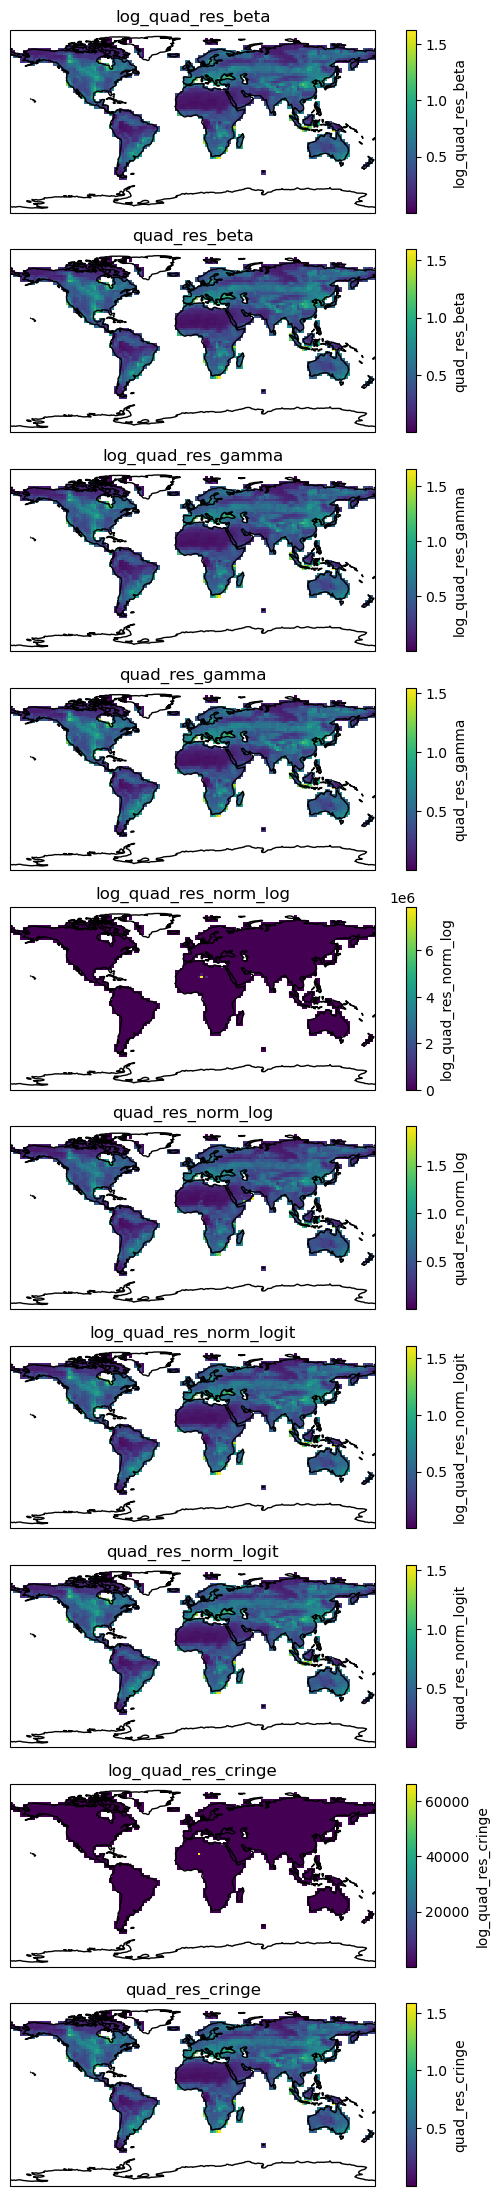

In [164]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=len(score_keys),
    ncols=1,
    figsize=(8, 28)
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



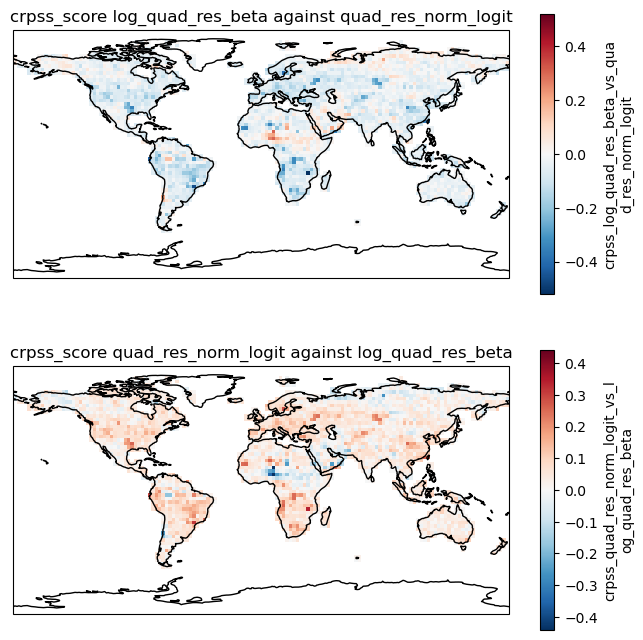

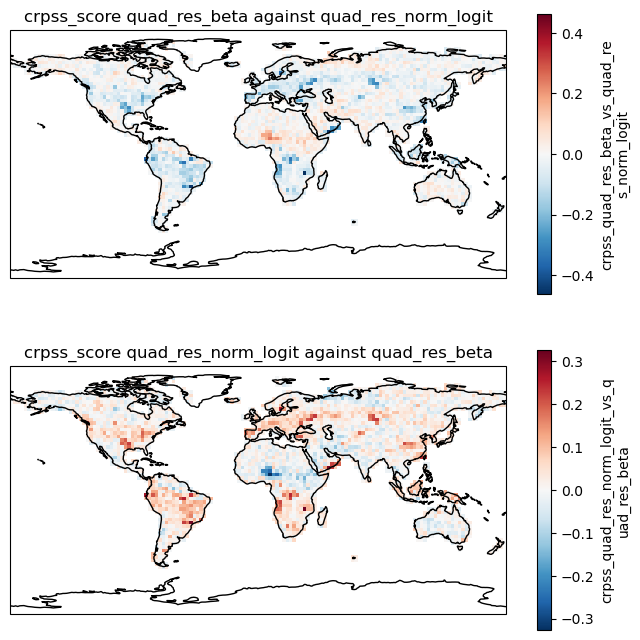

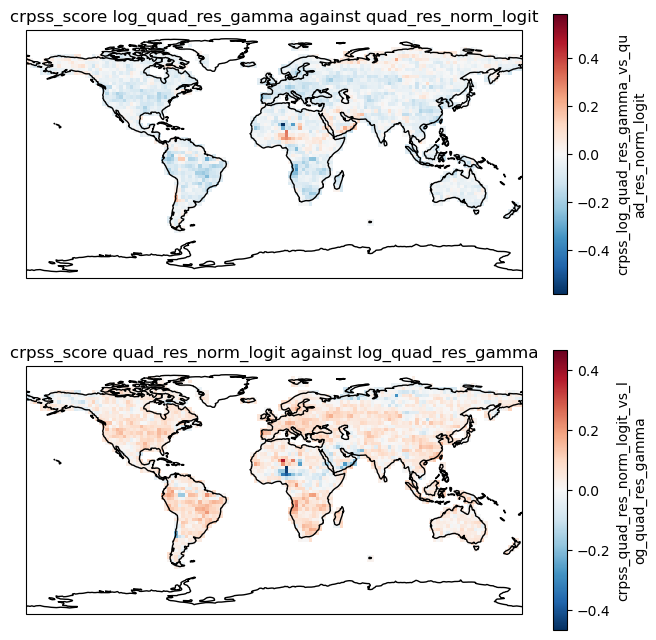

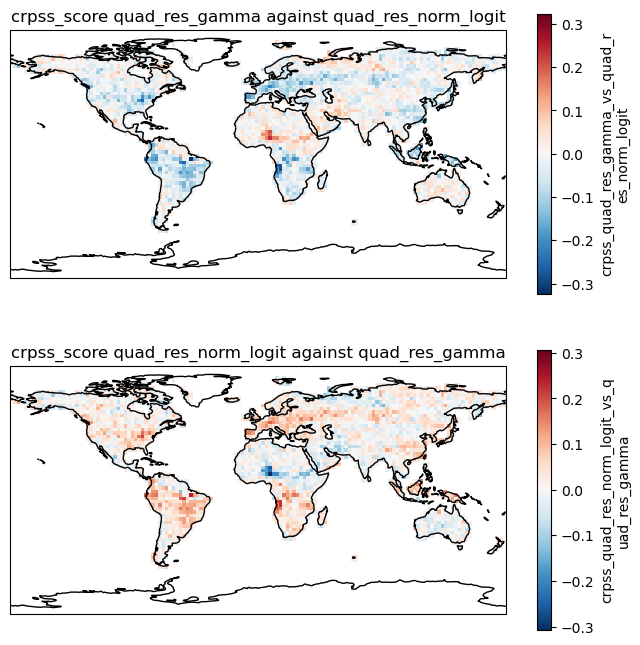

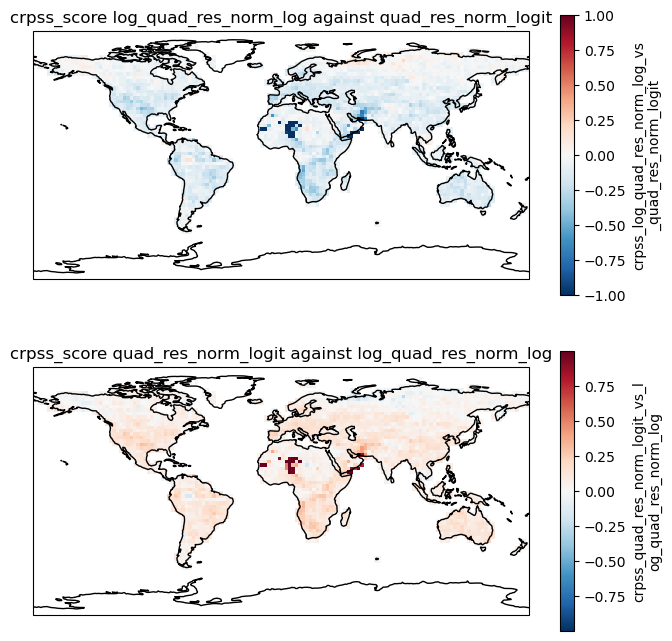

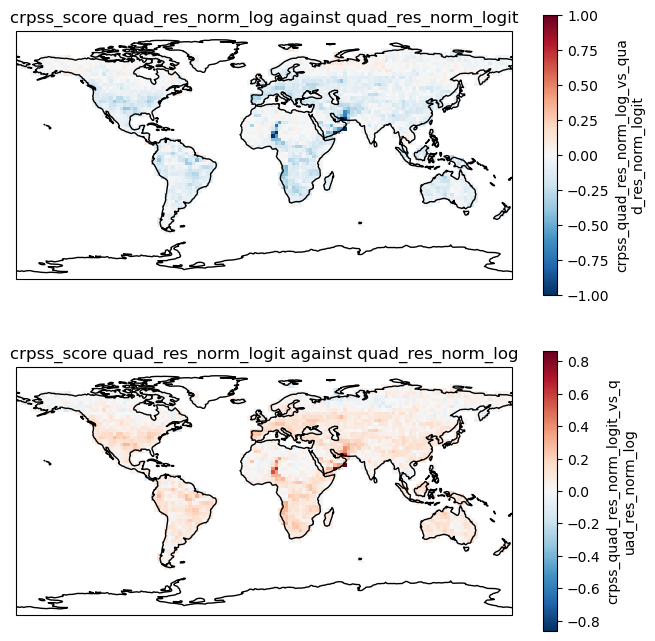

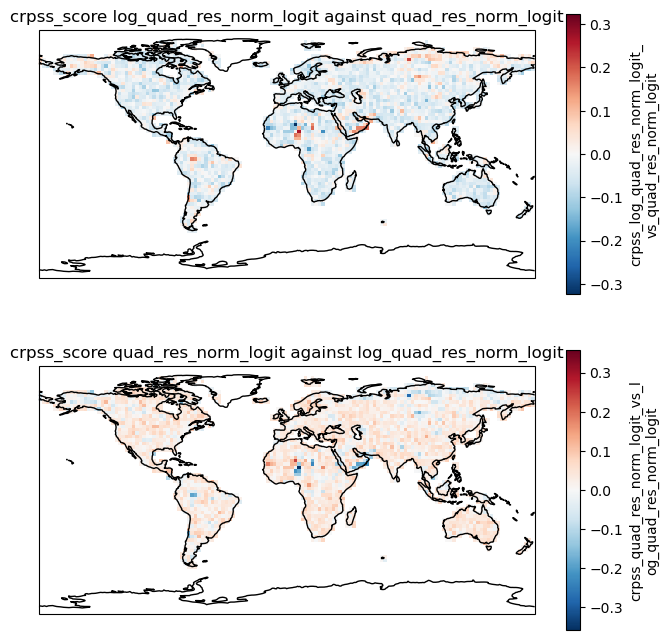

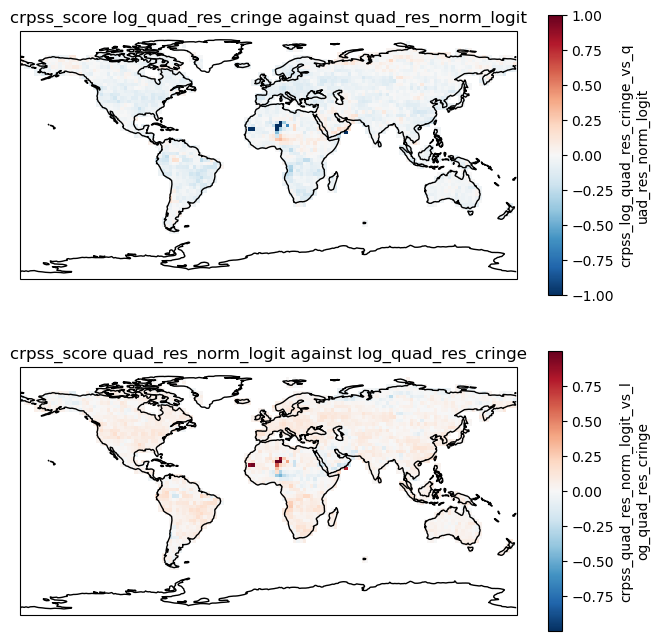

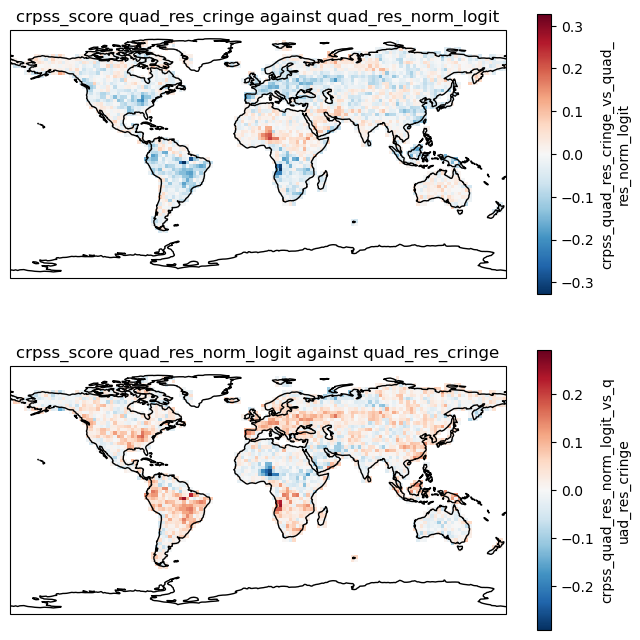

In [169]:
depth = 0

choice = "quad_res_norm_logit"

for i, s_key in enumerate(score_keys):
    if s_key == choice:
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets[choice].crps_score,score_sets[s_key].crps_score,choice,s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=2,
    ncols=1,
    figsize=(8, 8)
    )

    """
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time")[choice]
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(choice)
    """
    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_{choice}"].clip(min=-1)
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(f"crpss_score {s_key} against {choice}")

    da = vs.isel(depth=depth)[f"crpss_{choice}_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title(f"crpss_score {choice} against {s_key}")

    fig_global_crpss.show()
    
